In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, orth, qr
from scipy.optimize import curve_fit
from numpy import sin, cos, pi
cmap = plt.cm.plasma
from scipy.ndimage import gaussian_filter1d
from scipy.signal import wiener
from scipy.signal import wiener, butter, freqs, convolve, freqz
from scipy.fft import fft, ifft, fftshift, ifftshift, fftfreq
from scipy.interpolate import (RegularGridInterpolator, RectBivariateSpline,
                               interpn, griddata, Rbf, interp1d, interp2d)
import cv2
from scipy.signal import convolve2d as conv2
from skimage import color, data, restoration

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 45

8.030570172000001


In [34]:
m, n = 400, 10
w = 30  # width of the bump in # nodes
x = np.linspace(0, 1, m, endpoint=False)
mu_train = np.linspace(0.05, 1.05, n, endpoint=False)
mu_test = np.array([0.2, 0.22, 0.225, 0.23,  0.24, 0.25])
mu_validation = np.linspace(0, 1, m, endpoint=False)
sigma = 0.05
mode = "constant"
rank = 10
dx = 1/m

In [35]:
def plot_paramspace(X, ax=None):
    if not ax:
        print("new ax")
        fig, ax = plt.subplots(figsize=(4.59/2.54, 4.59/2.54))
    ax.imshow(X, interpolation="none", extent=(0, 1, 0, 1), aspect="auto")
    ax.set_xlabel("$\mu$")
    ax.set_ylabel("$x$")
    #ax.set_aspect(1/10)
    #plt.show()
    return ax

In [36]:
def bump(x, mu):
#     y = np.zeros_like(x)
#     i = np.argmin(np.abs(x-mu))
#     y[i:(i+w)] = 1.0
    w = 0.075
    y = np.zeros_like(x)
    y[np.abs(x-mu)<w/2] = 1.0
    return y

In [37]:
def predict(VT, grid, r, xi):
    method = "linear"
    V_interpolated = np.zeros((r, len(xi)))
    for mode in range(r):
        interpolator = interp1d(grid[0], VT[mode, :], kind=method, fill_value="extrapolate")
        V_interpolated[mode, :] = interpolator(xi)
    return V_interpolated

In [38]:
def gaussian(x, sigma, m, shift=True):
    # dont use cv2.getGaussianKernel(m, sigma)[:, 0], we need the gaussian to be centered at one single node!
    if shift:
        x_kernel = fftshift(x)
        offset = x_kernel[0]
    else:
        x_kernel = x
        offset = np.min(np.abs(x))  # or 0?
    A = 1/(m*sigma*(2*np.pi)**.5)
    return A * np.exp(-(x_kernel-offset)**2 / (2 * sigma**2))

def gaussian_f(sigma, m):
    # g_f = fft(g_x)
    # print(np.allclose(g_f, g_f2))
    # plt.plot(g_f, "bo")
    # plt.plot(g_f2, "r.")
    # plt.show()

    # Fourier Transform of the Gaussian by Konstantinos G. Derpanis
    f = np.fft.fftfreq(m, d=dx)
    omega = 2*np.pi*f
    return np.exp(-omega**2*sigma**2/2)

In [39]:
def convolve_f(y, g_f):
#     # alternative with mode = "wrap"
#     y_smooth2 = gaussian_filter1d(y, sigma/dx, mode="wrap", cval=0, truncate=20)
#     print(np.allclose(y_smooth, y_smooth2))
    y_f = fft(y)
    y_f_smooth = y_f*g_f
    y_smooth = ifft(y_f_smooth)
    return y_smooth.real

In [40]:
X_train = np.empty((m, len(mu_train)))
X_test = np.zeros((m, len(mu_test)))
X_validation = np.zeros((m, len(mu_validation)))

X_train_s = np.empty((m, len(mu_train)))
X_test_s = np.empty((m, len(mu_test)))
X_validation_s = np.empty((m, len(mu_validation)))

g_x = gaussian(x, sigma, m)
g_f = gaussian_f(sigma, m)

for _mu, _X, _X_s in zip([mu_train, mu_test, mu_validation], [X_train, X_test, X_validation], [X_train_s, X_test_s, X_validation_s]):
    for j, mu_j in enumerate(_mu):
        y = bump(x, mu_j)
        _X[:, j] = y
        _X_s[:, j] = convolve_f(y, g_f)

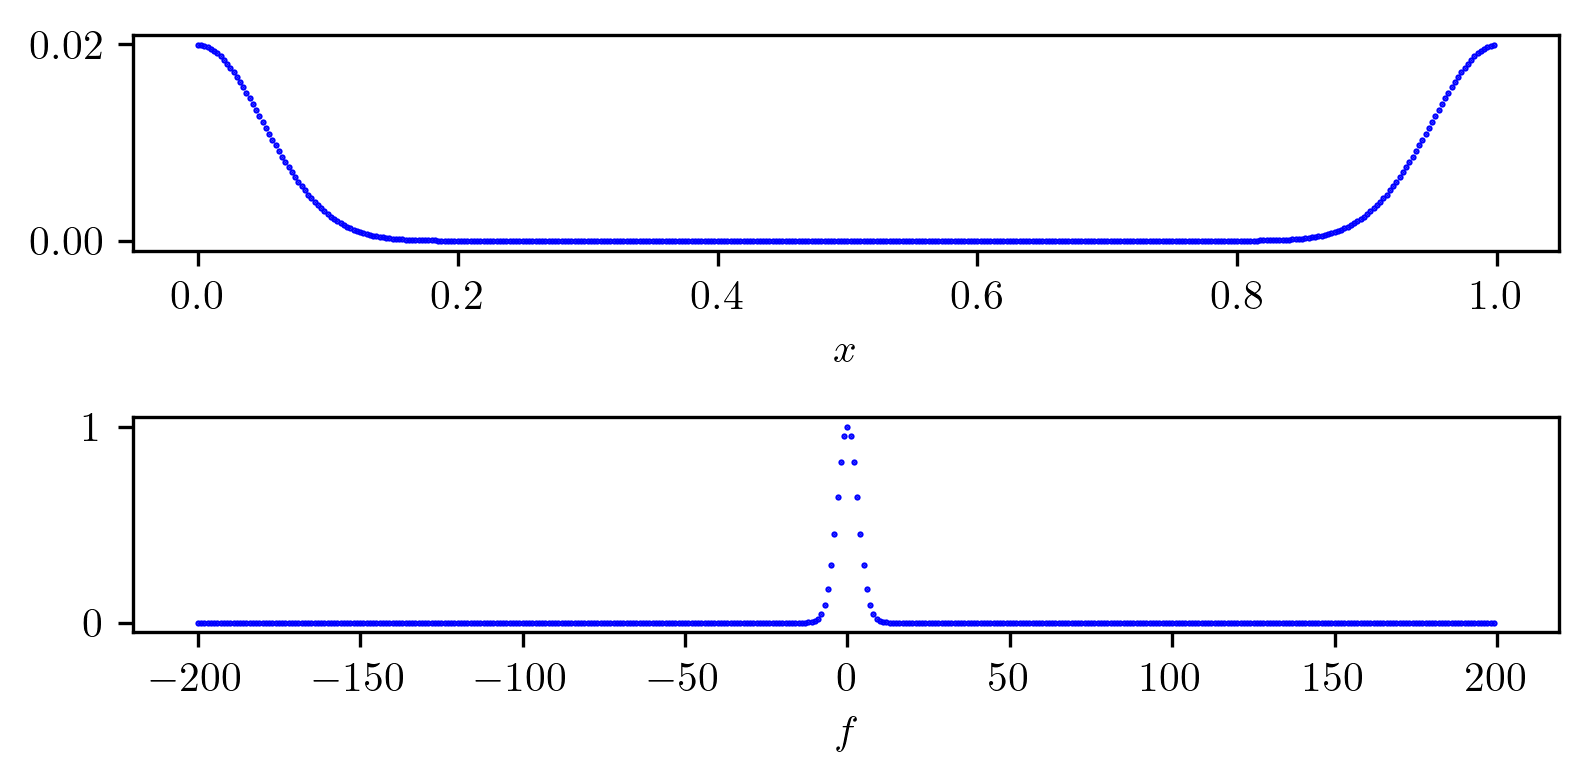

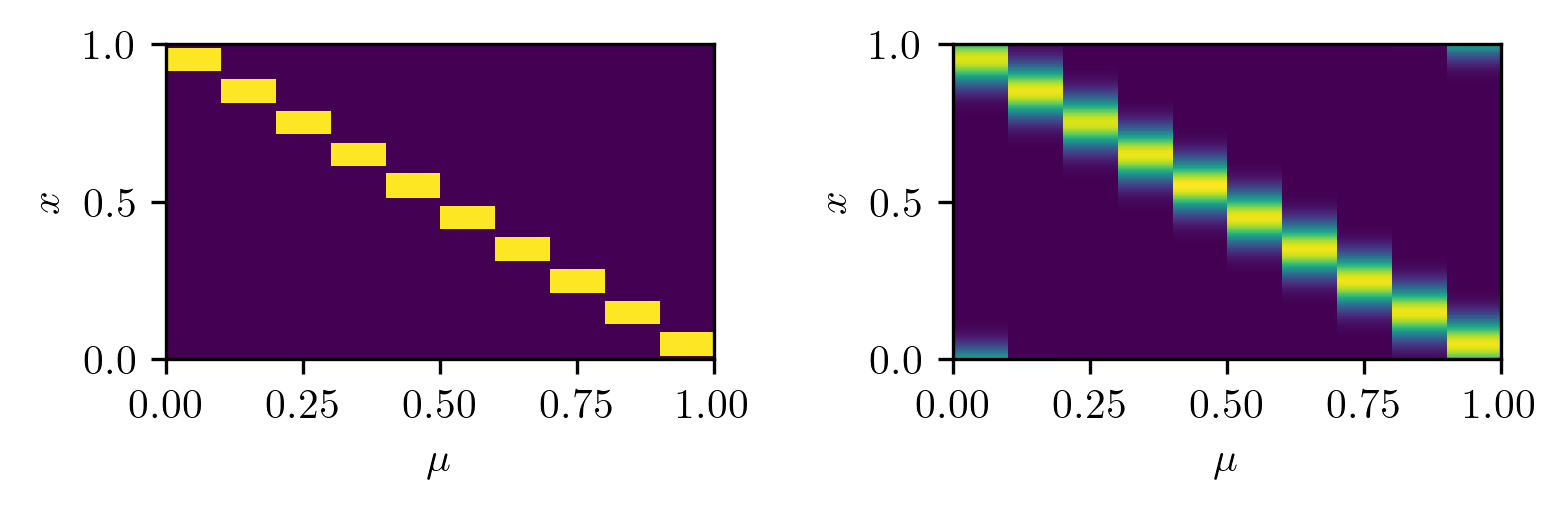

C:\Users\florianma\AppData\Local\Temp\ipykernel_18544\1437913537.py:38: MatplotlibDeprecationWarning: The label function was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use Tick.label1 instead.
  tick.label.set_fontsize(8)  # for some reasons it does not match


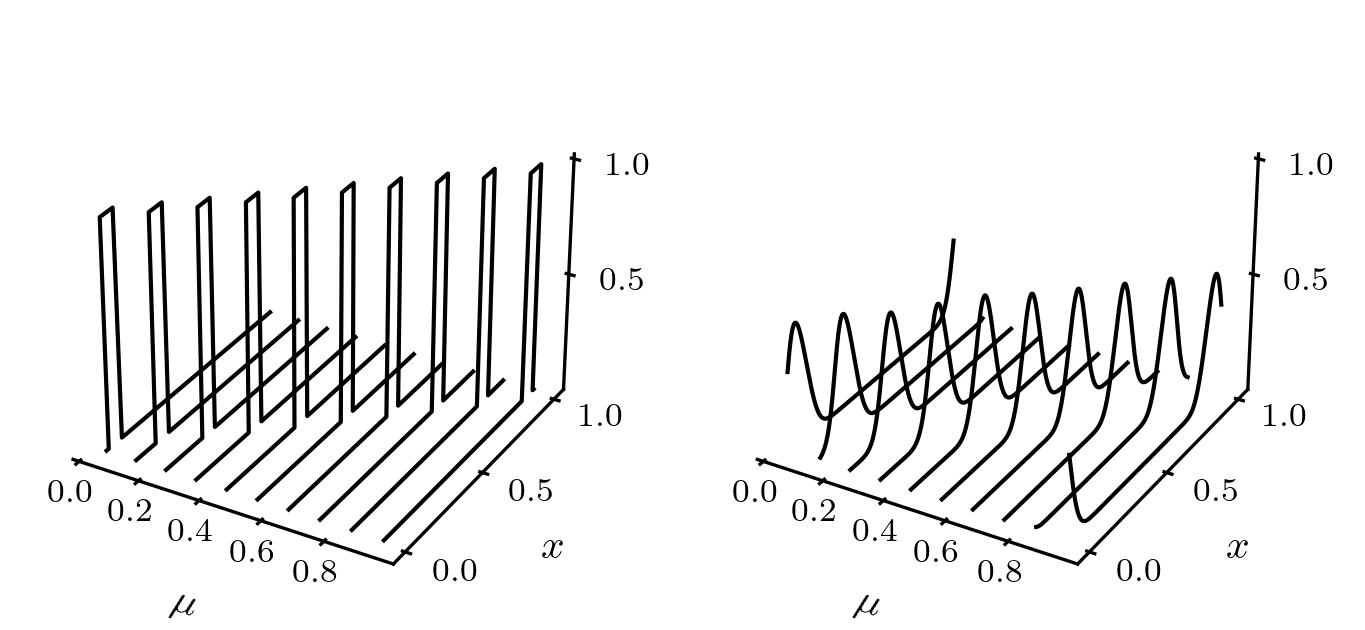

In [41]:
fix, axs = plt.subplots(2, 1, figsize=(page_width_in, page_width_in/2))
axs[0].plot(x, g_x, "b.", ms=1)
axs[1].plot(np.fft.fftfreq(m, d=dx), g_f, "b.", ms=1)
#axs[1].set_xlim(-50, 50)
axs[0].set_xlabel("$x$")
axs[1].set_xlabel("$f$")
plt.show()


# are the reduced coefficients the same? nope!
fig, axs = plt.subplots(1, 2, figsize=(page_width_in, page_width_in/3))
plot_paramspace(X_train, axs[0])
plot_paramspace(X_train_s, axs[1])
plt.show()

fig = plt.figure(figsize=(page_width_in, page_width_in/2), facecolor='white')
#fig, axs = plt.subplots(1, 2, figsize=(page_width_in/2, page_width_in/3))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

for i in range(len(mu_train)):
    ax1.plot(np.ones_like(x)*mu_train[i], x, X_train[:, i], "k-", lw=1)
    ax2.plot(np.ones_like(x)*mu_train[i], x, X_train_s[:, i], "k-", lw=1)
for ax in (ax1, ax2):
    ax.xaxis.labelpad = -5
    ax.yaxis.labelpad = -5
    xticks = [0.0, 0.2, 0.4, 0.6, 0.8]
    yticks = [0.0, 0.5, 1.0]
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.set_zticks([0.5, 1.0])
    ax.tick_params(axis='x', which='major', pad=-5)
    ax.tick_params(axis='y', which='major', pad=-2)
    ax.tick_params(axis='z', which='major', pad=0)
    ax.set_yticklabels(yticks, va='baseline', ha='left')
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        for tick in axis.get_major_ticks():
            tick.label.set_fontsize(8)  # for some reasons it does not match
        axis.pane.set_edgecolor('white')

    ax.grid(False)
    ax.set_facecolor('white')
    ax.xaxis.pane.fill = False  # Remove the background pane
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.set_xlabel("$\mu$")
    ax.set_ylabel("$x$")
#    ax.set_zlabel("$u(x; \mu)$")
    #ax.view_init(20,-120)
plt.show()


In [42]:
def neares_neighbour(x, x_all):
    return np.min(np.abs(x-x_all))


def get_sigma(sigma, x_sample, x_test, c):
    d = neares_neighbour(x_sample, x_test)
    dx = x_test[1]-x_test[0]
    return sigma*(1+ c*d/dx)


def richardson_lucy(im_blur, sgm, num_iter=1000, clip=False, filter_epsilon=None):
    psf_f = gaussian_f(sgm, m)
    im_deconv = im_blur.copy()

    # Small regularization parameter used to avoid 0 divisions
    eps = 1e-12

    for _ in range(num_iter):
        #blurred = convolve(im_deconv, psf, mode='same') + eps
        blurred = convolve_f(im_deconv, psf_f) + eps
        if filter_epsilon:
            relative_blur = np.where(blurred < filter_epsilon, 0, im_blur / blurred)
        else:
            relative_blur = im_blur / blurred
        #print(_, np.min(relative_blur), np.max(relative_blur))
        #im_deconv *= convolve(relative_blur, psf_mirror, mode='same')
        im_deconv *= convolve_f(relative_blur, psf_f)
        

    if clip:
        im_deconv[im_deconv > 1] = 1
        im_deconv[im_deconv < -1] = -1

    return im_deconv

In [59]:
U, S, VT = np.linalg.svd(X_train, False)
U_s, S_s, VT_s = np.linalg.svd(X_train_s, False)

U_s, S_s, VT_s = U_s[:, :rank], S_s[:rank], VT_s[:rank]
U, S, VT = U[:, :rank], S[:rank], VT[:rank]

VT_test_intp = predict(VT, [mu_train,], rank, mu_test)
VT_validation_intp = predict(VT, [mu_train,], rank, mu_validation)
X_test_intp = (U*S) @ VT_test_intp
X_validation_intp = (U*S) @ VT_validation_intp

VT_test_intp_s = predict(VT_s, [mu_train,], rank, mu_test)
VT_validation_intp_s = predict(VT_s, [mu_train,], rank, mu_validation)
X_test_intp_s = (U_s*S_s) @ VT_test_intp_s
X_validation_intp_s = (U_s*S_s) @ VT_validation_intp_s

# TODO: richarson Lucy deconv.!

# physics informed post processing. Here: find largest 3 elements.
# other options: wiener deconvolution, threshold methods, ... 
X_test_intp_s_post = np.zeros_like(X_test_intp_s)
for j, _mu_ in enumerate(mu_test):
    sgm_est = get_sigma(sigma, mu_test[j], mu_train, c=1)
    X_test_intp_s_post[:, j] = richardson_lucy(X_test_intp_s[:, j], sgm_est, num_iter=100)
    print(mu_test[j], sgm_est)
#     ind = np.argpartition(X_test_intp_s[:, j], -30)[-30:]
#     X_test_intp_s_post[ind, j] = 1
#print(np.sum(bump(x, xi[1])>.5), np.sum(X_test_intp_s_post[:, 1]>.5))

0.2 0.075
0.22 0.06499999999999999
0.225 0.0625
0.23 0.06
0.24 0.05500000000000001
0.25 0.05


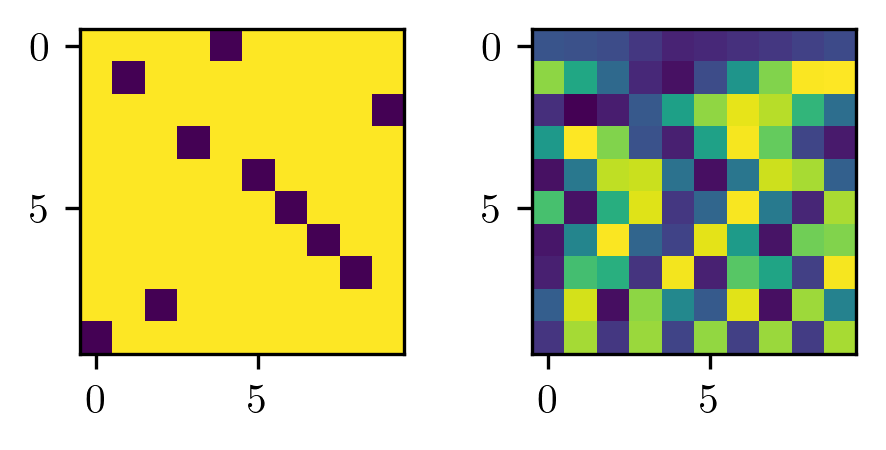

array([1.17560445, 1.22124604, 1.23606474, 1.45181587, 1.47719763,
       1.95100369, 1.96446922, 2.8360029 , 2.80071196, 3.52334613])

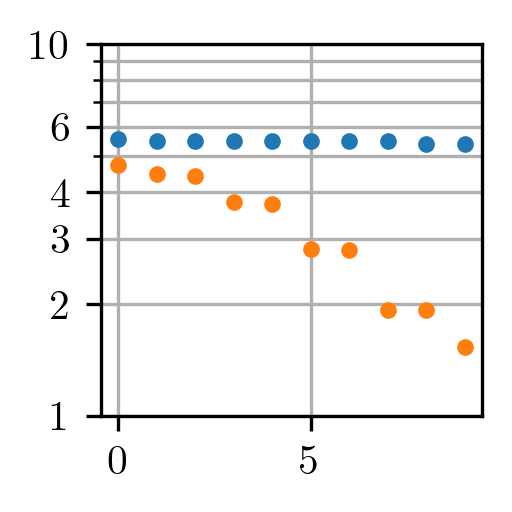

In [60]:
# are the reduced coefficients the same? nope!
fig, axs = plt.subplots(1, 2)
axs[0].imshow(VT)
axs[1].imshow(VT_s)
plt.show()

fig, ax = plt.subplots(figsize=(4.59/2.54, 4.59/2.54))
ax.plot(S, ".")
ax.plot(S_s, ".")
ax.set_yscale('log')
ax.set_ylim([1, 10])
#ax.ticklabel_format(useOffset=False, style='plain')
ax.set_yticks([1, 2, 3, 4, 6, 10])
ax.set_yticklabels([1, 2, 3, 4, 6, 10])
#import matplotlib.ticker as mticker
#ax.get_yaxis().set_major_formatter(mticker.ScalarFormatter())
#ax.get_yaxis().set_minor_formatter(mticker.ScalarFormatter())
plt.grid(which="minor")
plt.grid(which="major")
S/S_s

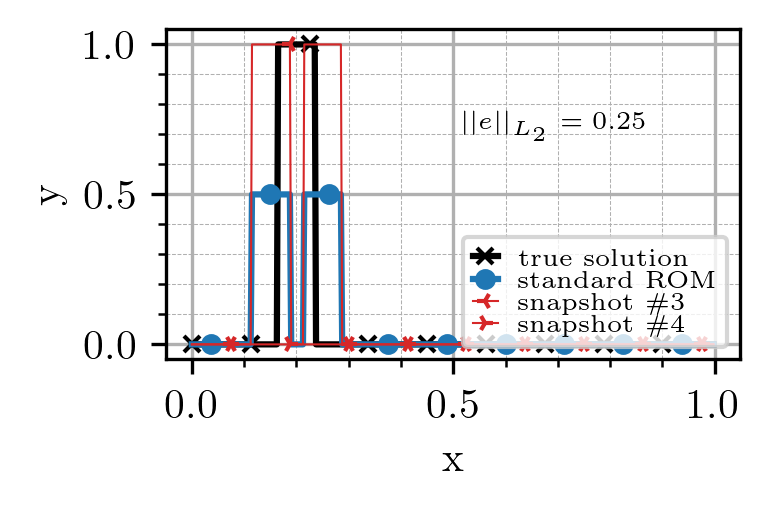

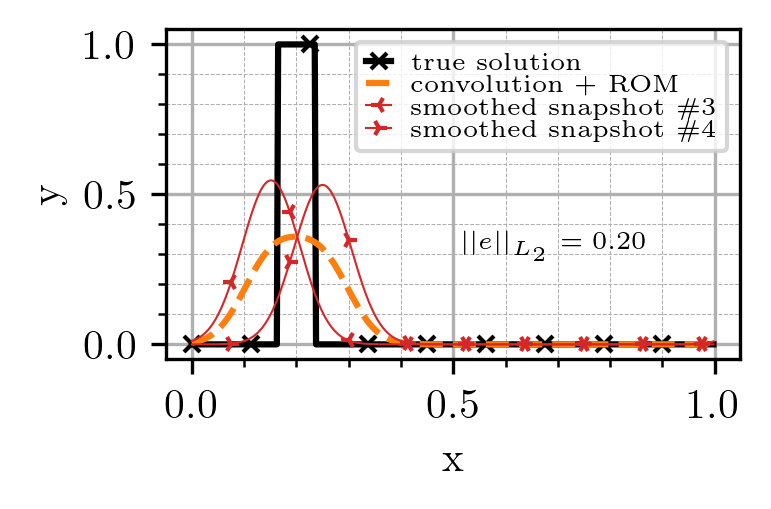

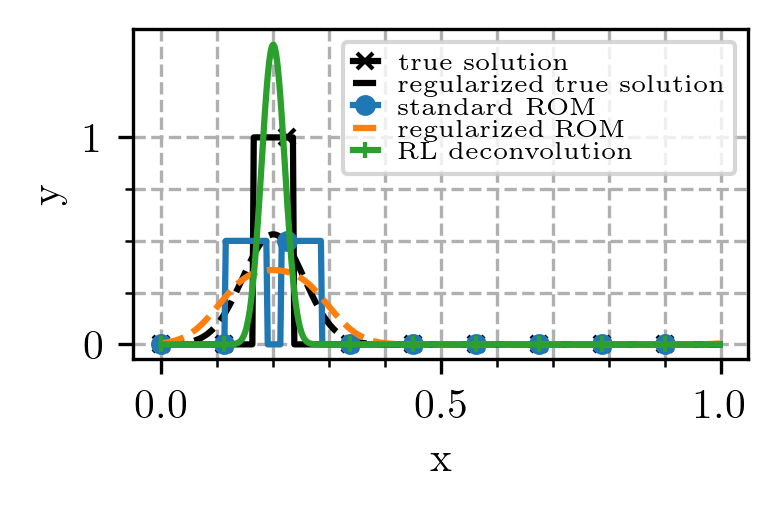

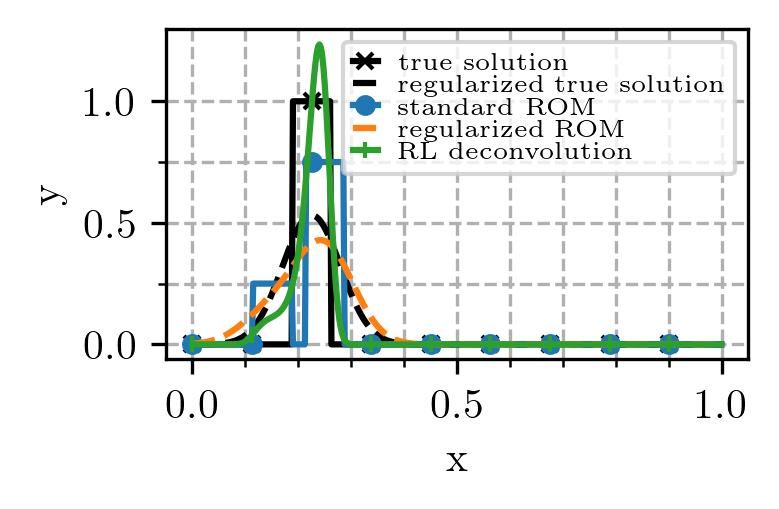

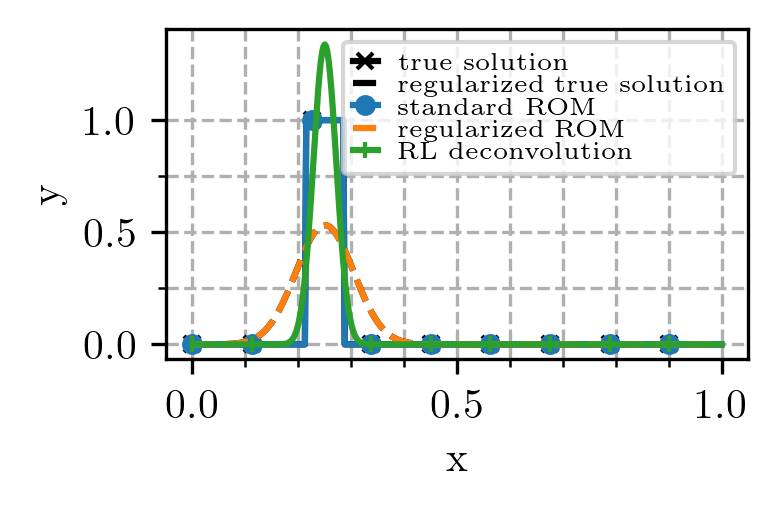

In [61]:
mu_plot = 0.2

fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
plt.plot(x, bump(x, mu_plot), "kx-", ms=4, markevery=(0, markevery), label="true solution")
plt.plot(x, X_test_intp[:, 0], "C0o-", ms=4, markevery=(15, markevery), label="standard ROM")
plt.plot(x, X_train[:, 1], "C33-", ms=4, lw=.5, markevery=(30, markevery), label="snapshot \#3")
plt.plot(x, X_train[:, 2], "C34-", ms=4, lw=.5, markevery=(30, markevery), label="snapshot \#4")
#plt.plot(x, X_intp_c[:, 0], "r.-", label="convolution + ROM")
#plt.plot(x, X_c[:, 3], "r--", lw=1, label="closest smoothened snapshot (left)")
#plt.plot(x, X_c[:, 4], "r--", lw=1, label="closest smoothened snapshot (right)")
ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
plt.legend(loc="lower right")
e = np.mean((bump(x, mu_plot)-X_test_intp[:, 0])**2)**.5
ax.text(0.52, 0.72, "$||e||_{L_2}"+"={:.2f}$".format(e), fontsize=6)
plt.xlabel("x")
plt.ylabel("y")
plt.show()


fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
plt.plot(x, bump(x, mu_plot), "kx-", ms=4, markevery=markevery, label="true solution")
#plt.plot(x, X_test_intp[:, 0], "b.-", label="ROM")
plt.plot(x, X_test_intp_s[:, 0], "C1--", ms=4, markevery=markevery, label="convolution + ROM")
#plt.plot(x, X[:, 3], "r--", lw=1, label="closest snapshot (left)")
#plt.plot(x, X[:, 4], "r--", lw=1, label="closest snapshot (right)")
plt.plot(x, X_train_s[:, 1], "C33-", lw=.5, ms=4, markevery=(30, markevery), label="smoothed snapshot \#3")
plt.plot(x, X_train_s[:, 2], "C34-", lw=.5, ms=4, markevery=(30, markevery), label="smoothed snapshot \#4")
ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
plt.legend()
e = np.mean((bump(x, mu_plot)-X_test_intp_s[:, 0])**2)**.5
ax.text(0.52, 0.32, "$||e||_{L_2}"+"={:.2f}$".format(e), fontsize=6)
plt.xlabel("x")
plt.ylabel("y")
plt.show()


for j in [0, 2, 5]:
    fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
    plt.plot(x, X_test[:, j], "kx-", ms=4, markevery=markevery, label="true solution")
    plt.plot(x, X_test_s[:, j], "k--", ms=4, markevery=markevery, label="regularized true solution")
    plt.plot(x, X_test_intp[:, j], "C0o-", ms=4, markevery=markevery, label="standard ROM")
    plt.plot(x, X_test_intp_s[:, j], "C1--", ms=4, markevery=markevery, label="regularized ROM")
    plt.plot(x, X_test_intp_s_post[:, j], "C2|-", ms=4, markevery=markevery, label="RL deconvolution")
    ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(0, 1, 5, endpoint=True), minor=True)
    plt.grid(True, which='minor', linestyle='--')
    plt.grid(True, which='major', linestyle='--')
    plt.legend()
    plt.xlabel("x")
    plt.ylabel("y")

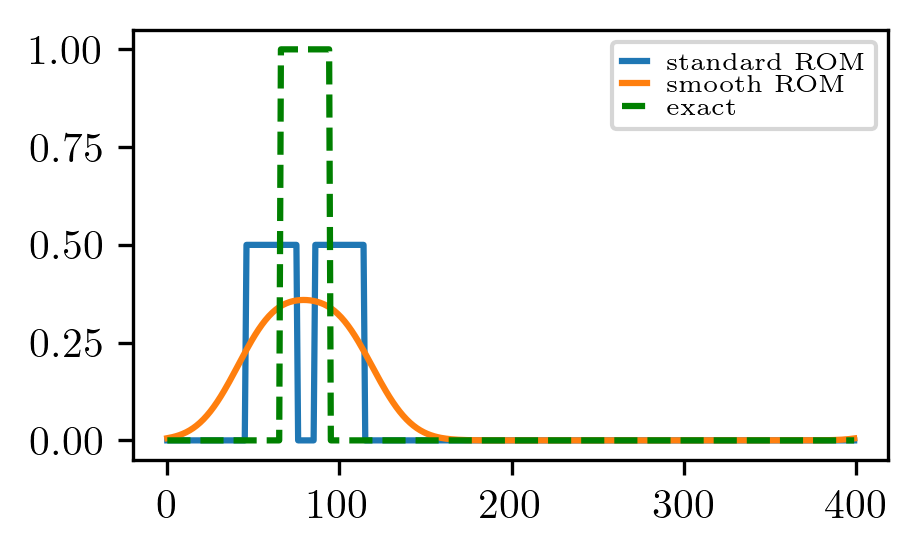

0.0


C:\Users\florianma\AppData\Local\Temp\ipykernel_18544\3498603413.py:50: RuntimeWarning: divide by zero encountered in true_divide
  plt.plot(np.fft.fftfreq(m, d=dx), exact_smoothed / ss_f, "C3.", label="ideal filter?")
C:\Users\florianma\AppData\Local\Temp\ipykernel_18544\3498603413.py:50: RuntimeWarning: invalid value encountered in true_divide
  plt.plot(np.fft.fftfreq(m, d=dx), exact_smoothed / ss_f, "C3.", label="ideal filter?")


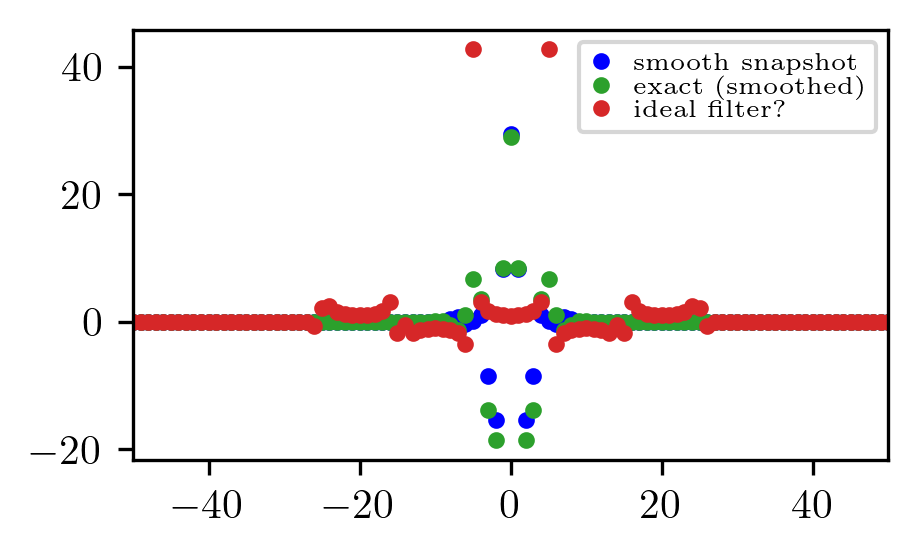

In [58]:
def neares_neighbour(x, x_all):
    return np.min(np.abs(x-x_all))

p = 0

plt.plot(X_test_intp[:, p], label="standard ROM")
plt.plot(X_test_intp_s[:, p], label="smooth ROM")
b1 = X_test[:, p]
plt.plot(b1, "g--", label="exact")
#b2 = convolve_f(b1, np.exp(-omega**2*(sigma/10)**2/2))
#plt.plot(b2, "C3-", label="exact2")
plt.legend()
plt.show()

x_sample = mu_test[p]
# project into frequency
ss_f = fft(X_test_intp_s[:, p])
exact_smoothed = fft(bump(x, x_sample))*g_f
# calc nearest neighbour distance c = min(dist(x-xi))
c = neares_neighbour(x_sample, mu_test)
print(c)
#     # gaussian kernel with sigma=sigma+c*p 
#     print(sigma+c*p)
#     q = cv2.getGaussianKernel(X_test_intp_s[:, p].size, sigma+c*p)[:, 0]
#     # project into frequency q_f = 
#     q_f = fft(ifftshift(q))
# omega = 2*np.pi*f
# q_f = np.exp(-omega**2*(sigma+c*p)**2/2)
# desmooth

# N = 5  # Order of the filter
# Wn = 50/400  # Cutoff frequency as a fraction of Nyquist rate
# b, a = butter(N, Wn, btype='low')
# w, h = freqz(b, a, worN=m)
# butter_filter = np.abs(h)

#sss_f = ss_f*(1 / q_f) #*butter_filter
#     sss_f[np.isnan(sss_f)] = 0
#     sss_f[sss_f>10] = 0
#     sss_f[sss_f<-10] = 0
#     print(np.min(sss_f), np.max(sss_f))
plt.plot(np.fft.fftfreq(m, d=dx), ss_f, "b.", label="smooth snapshot")
# plt.plot(f, q_f, "C1.", label="smoothing kernel")
# q_f2 = np.exp(-omega**2*(sigma/10)**2/2)
#   plt.plot(f, qf2,"c.")
# plt.plot(f, np.abs(h), "r.", label="butterworth")
#plt.plot(f, sss_f, "k.", label="sharpened snapshot snapshot")
#    plt.plot(f, fft(bump(x, x_sample)), "g.", label="exact")
plt.plot(np.fft.fftfreq(m, d=dx), exact_smoothed, "C2.", label="exact (smoothed)")
plt.plot(np.fft.fftfreq(m, d=dx), exact_smoothed / ss_f, "C3.", label="ideal filter?")
#    plt.plot(f, fft(bump(x, x_sample))/ss_f, "C4.", label="wtf")


plt.legend()
#plt.gca().set_yscale('log')
#plt.ylim(-10, 10)
plt.xlim(-50, 50)
plt.show()



0 54 0.11363636363636363 2.6311424864268576
1 92 0.18656565656565657 2.6160482875808495
2 87 0.17696969696969697 2.4886844954338274
3 43 0.09252525252525252 2.2089354845900244
4 79 0.16161616161616163 2.2257365178944726
5 76 0.15585858585858586 2.098020393705434
6 74 0.15202020202020203 1.9796554378879965
7 72 0.1481818181818182 1.876350597464771
8 71 0.14626262626262626 1.7932080395832435
9 71 0.14626262626262626 1.734295618845784
10 71 0.14626262626262626 1.7022722266436383
11 71 0.14626262626262626 1.6973420927498288
12 72 0.1481818181818182 1.7182762550389594
13 72 0.1481818181818182 1.7616133065890562
14 76 0.15585858585858586 1.8640126153382688
15 73 0.1501010101010101 1.815801224341051
16 72 0.1481818181818182 1.809767410177355
17 72 0.1481818181818182 1.8053377733266587
18 71 0.14626262626262626 1.8025559506495492
19 20 0.04838383838383838 1.8001090950898668
20 70 0.14434343434343436 1.8006181611512928


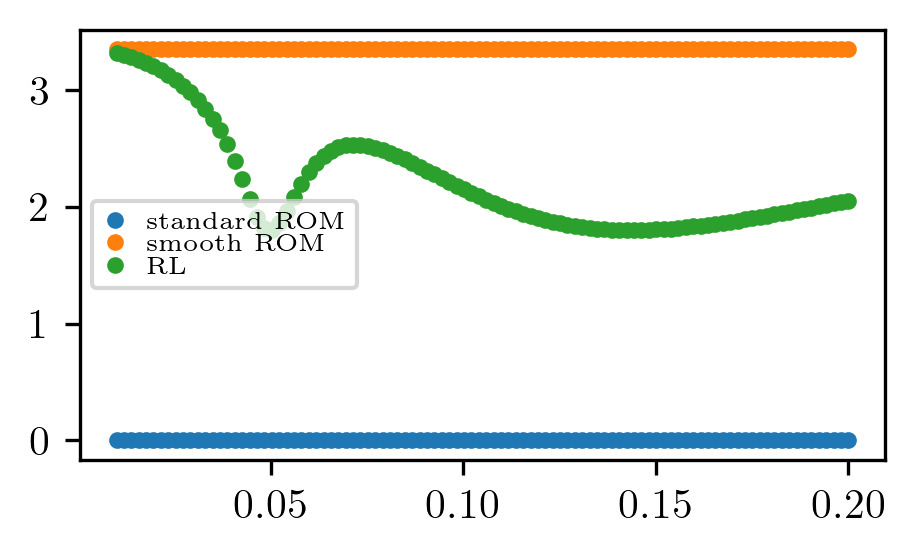

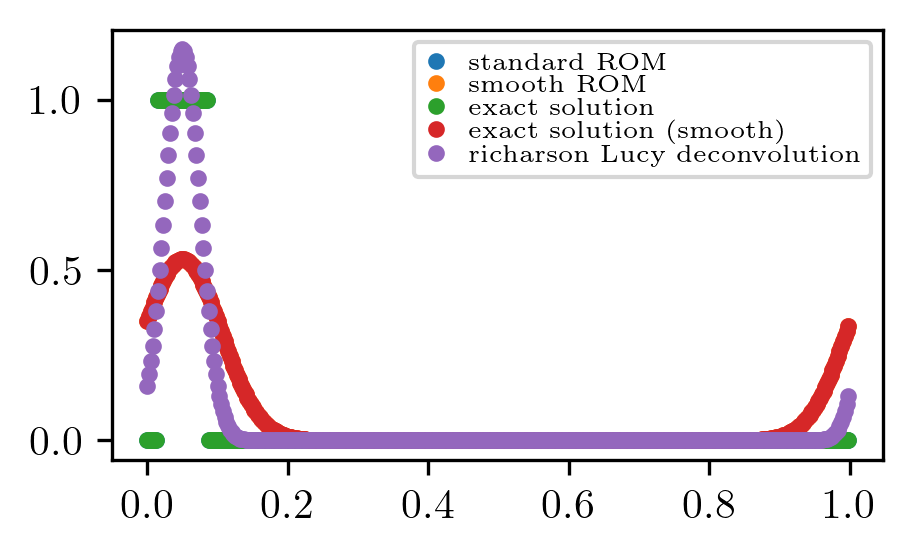

21 69 0.14242424242424243 1.8008796701546974
22 68 0.14050505050505052 1.8016594106803843
23 67 0.1385858585858586 1.8026886759216099
24 66 0.1366666666666667 1.803733853167113
25 65 0.13474747474747475 1.8046014610381476
26 63 0.13090909090909092 1.8050009679925823
27 64 0.13282828282828282 1.8793216849012073
28 62 0.128989898989899 1.8781603290369173
29 62 0.128989898989899 1.8552369722587982
30 58 0.1213131313131313 1.8013890875826009
31 57 0.11939393939393939 1.7993376828931846
32 55 0.11555555555555555 1.7970460661992174
33 38 0.08292929292929292 1.854783848851559
34 39 0.08484848484848484 1.8485319987047408
35 40 0.08676767676767676 1.8432154435352752
36 43 0.09252525252525252 1.7887402571314936
37 44 0.09444444444444444 1.7887671152355151
38 44 0.09444444444444444 1.7898615891607148
39 45 0.09636363636363636 1.7919298633569136
40 45 0.09636363636363636 1.7948070813482935
41 44 0.09444444444444444 1.798331742446992
42 41 0.08868686868686868 1.8794489542127262
43 39 0.084848484848

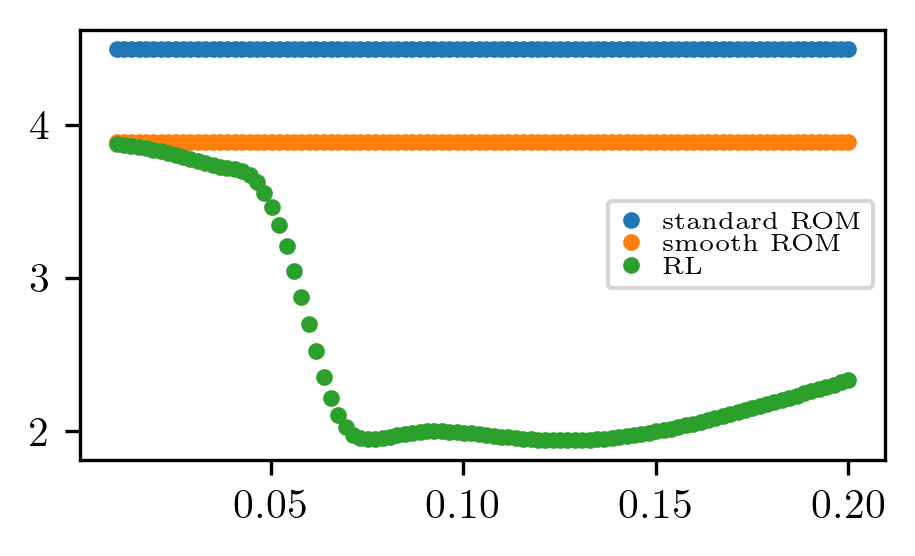

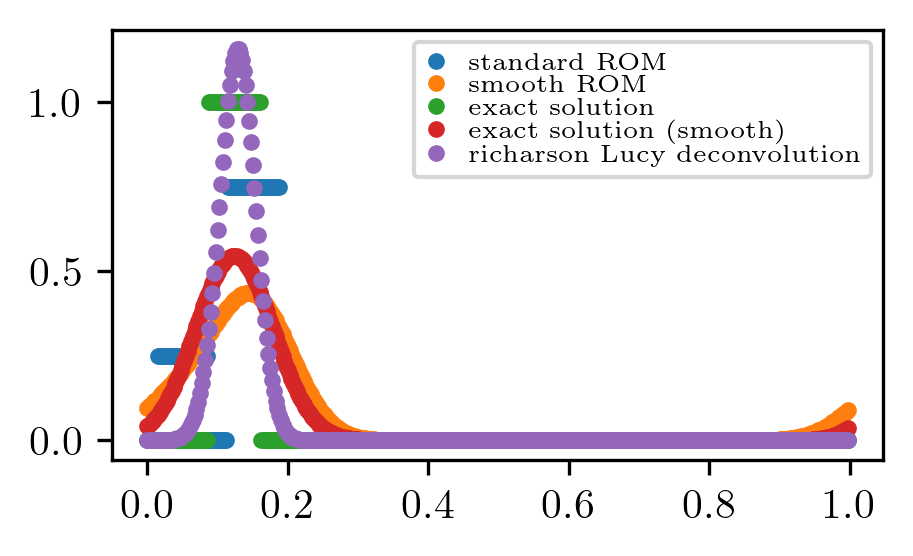

51 60 0.12515151515151515 1.8457655460275262
52 62 0.128989898989899 1.8445044853992851
53 63 0.13090909090909092 1.8413816679706263
54 64 0.13282828282828282 1.8368401303910773
55 66 0.1366666666666667 1.830821998934509
56 69 0.14242424242424243 1.8452434994320133
57 70 0.14434343434343436 1.840754745521531
58 71 0.14626262626262626 1.885757798329081
59 73 0.1501010101010101 1.873734810200633
60 74 0.15202020202020203 1.8620164585440964
61 73 0.1501010101010101 1.8529345179740835
62 72 0.1481818181818182 1.8465238369367079
63 69 0.14242424242424243 1.7878411182406428
64 68 0.14050505050505052 1.7890047641125864
65 66 0.1366666666666667 1.790922926543417
66 65 0.13474747474747475 1.7931588363955706
67 64 0.13282828282828282 1.7954278118778997
68 63 0.13090909090909092 1.7974463320051512
69 63 0.13090909090909092 1.870508213071607
70 62 0.128989898989899 1.87203939855033
71 61 0.12707070707070708 1.8402282095347868
72 60 0.12515151515151515 1.8397958338063347
73 37 0.081010101010101 1.7

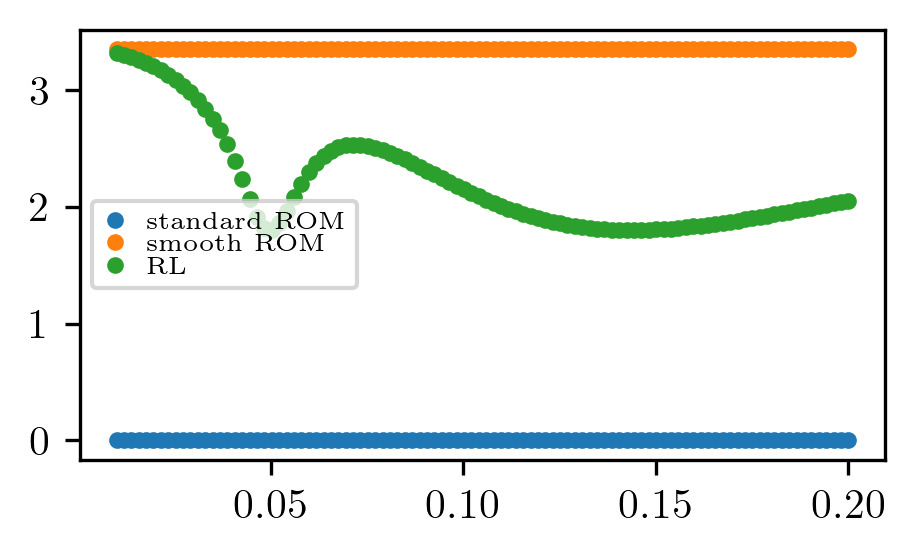

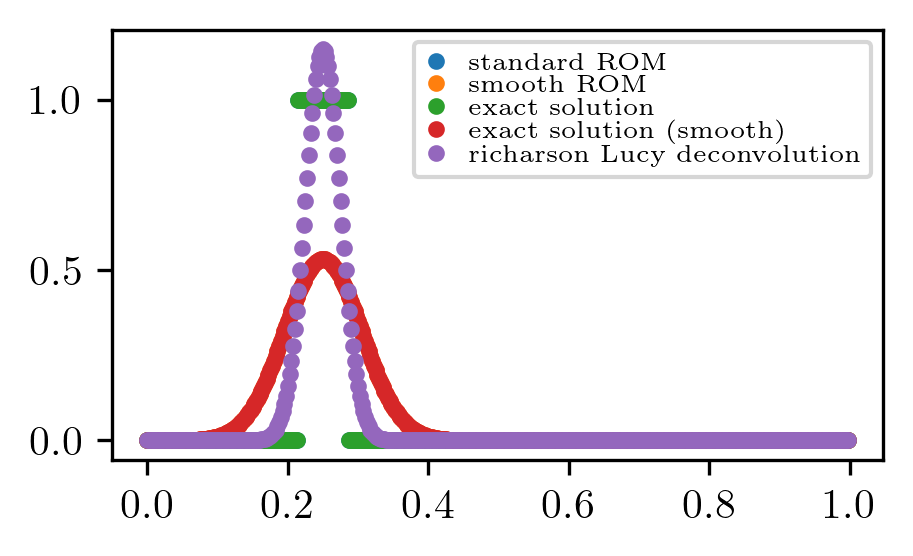

101 71 0.14626262626262626 1.8679152109710828
102 70 0.14434343434343436 1.871164824996216
103 69 0.14242424242424243 1.8742133031282133
104 68 0.14050505050505052 1.8768078921583493
105 66 0.1366666666666667 1.8785818455384589
106 65 0.13474747474747475 1.879438967325514
107 64 0.13282828282828282 1.879321684901204
108 62 0.128989898989899 1.8781603290369149
109 61 0.12707070707070708 1.8757210761725174
110 60 0.12515151515151515 1.8723533715845968
111 58 0.1213131313131313 1.8681708033232698
112 37 0.081010101010101 1.8620443181661641
113 38 0.08292929292929292 1.8547838488515553
114 39 0.08484848484848484 1.8485319987047368
115 40 0.08676767676767676 1.8432154435352712
116 40 0.08676767676767676 1.8541277350483027
117 41 0.08868686868686868 1.8559149637063406
118 41 0.08868686868686868 1.8586981480269738
119 42 0.0906060606060606 1.8626092603737427
120 42 0.0906060606060606 1.8674328802933589
121 42 0.0906060606060606 1.8731826308261361
122 41 0.08868686868686868 1.8794489542127255


282 40 0.08676767676767676 1.859620433524148
283 38 0.08292929292929292 1.8882879507254546
284 39 0.08484848484848484 1.8730954063772642
285 37 0.081010101010101 1.8997593723323751
286 38 0.08292929292929292 1.8888907210510428
287 36 0.07909090909090909 1.9143372254859758
288 36 0.07909090909090909 1.9059859587945238
289 62 0.128989898989899 1.9290654743685662
290 61 0.12707070707070708 1.9192699419320198
291 65 0.13474747474747475 1.9327999690485682
292 64 0.13282828282828282 1.9203661389461137
293 68 0.14050505050505052 1.930809513423619
294 69 0.14242424242424243 1.9275576272631274
295 70 0.14434343434343436 1.9231672672062925
296 71 0.14626262626262626 1.9178756479471624
297 71 0.14626262626262626 1.8378618737873347
298 74 0.15202020202020203 1.9057555274862603
299 73 0.1501010101010101 1.8327352246763302
300 20 0.04838383838383838 1.8903481013527446
301 73 0.1501010101010101 1.8327352246763298
302 74 0.15202020202020203 1.8896324017396031
303 71 0.14626262626262626 1.8378618737873

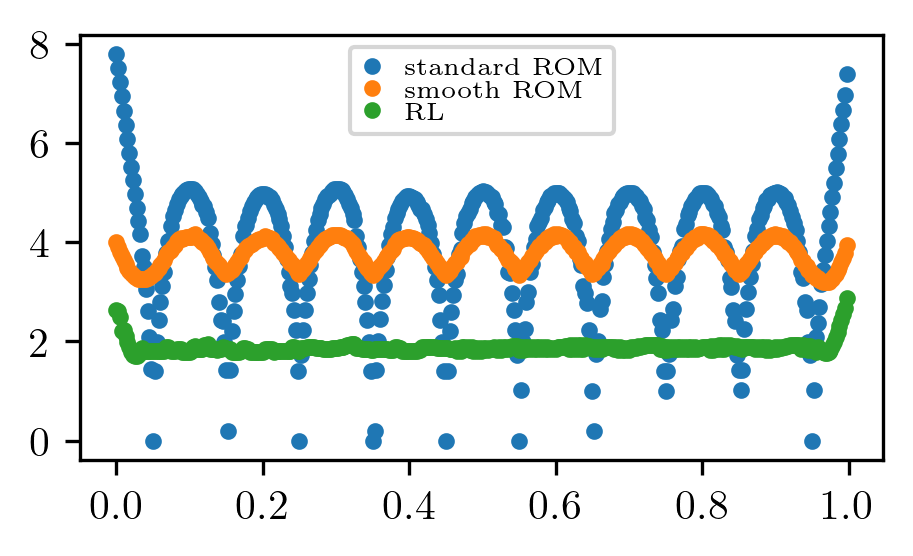

C:\Users\florianma\AppData\Local\Temp\ipykernel_18544\1097263277.py:55: RuntimeWarning: divide by zero encountered in true_divide
  print(np.mean(esROM/eROM))


inf


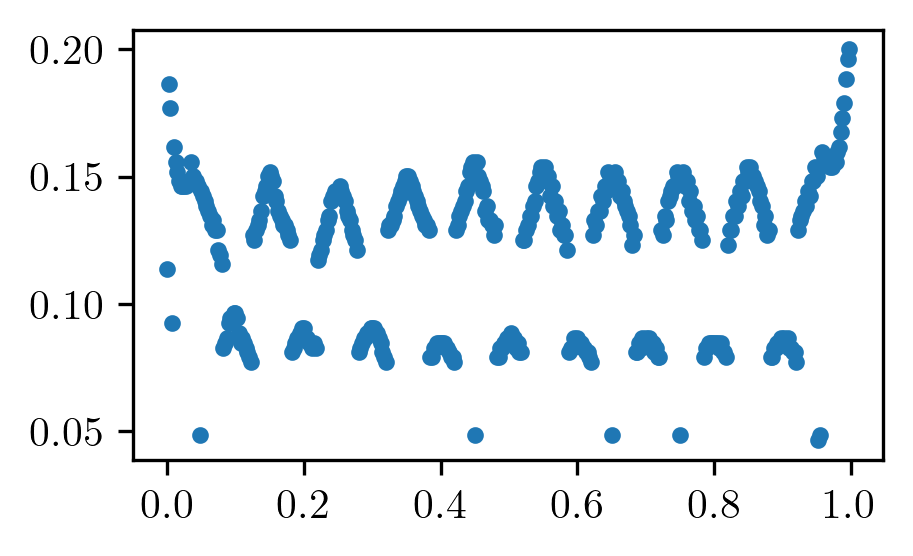

In [46]:
sgms = np.linspace(0.01, 0.2, 100)
e = np.empty((len(mu_validation),100),)

esROM = np.empty(len(mu_validation), )
eROM = np.empty(len(mu_validation), )
esROMs = np.empty(len(mu_validation), )
sgm_opt = np.empty(len(mu_validation), )

num_iter = 30
for p in range(len(mu_validation)):

    exact = X_validation[:, p]
    standard_ROM = X_validation_intp[:, p]
    blurred = np.copy(X_validation_intp_s[:, p])
    esROM[p] = np.sum((blurred-X_validation[:, p])**2)**.5
    eROM[p] = np.sum((standard_ROM-X_validation[:, p])**2)**.5

   
    for i, sgm in enumerate(sgms):
        
        psf_f = gaussian_f(sgm, m)
        deconvolved_RL = richardson_lucy(blurred, sgm, num_iter=num_iter, clip=False)
        e[p, i] = np.sum((deconvolved_RL-X_validation[:, p])**2)**.5

    ind = np.argmin(e[p])
    sgm_opt[p] = sgms[ind]
    esROMs[p] = e[p, ind]

    print(p, ind, sgm_opt[p], e[p, ind])

    if p in (20, 50, 100):
        plt.plot(sgms, e[p]*0+eROM[p], "C0.", label="standard ROM")
        plt.plot(sgms, e[p]*0+esROM[p], "C1.", label="smooth ROM")
        plt.plot(sgms, e[p], "C2.", label="RL")
        plt.legend()
        plt.show()

        deconvolved_RL = richardson_lucy(blurred, sgm_opt[p], num_iter=num_iter, clip=False)

        plt.plot(x, standard_ROM, "C0.", label="standard ROM")
        plt.plot(x, blurred, "C1.", label="smooth ROM")
        plt.plot(x, X_validation[:, p], "C2.", label="exact solution")
        plt.plot(x, X_validation_s[:, p], "C3.", label="exact solution (smooth)")
        plt.plot(x, deconvolved_RL, "C4.", label="richarson Lucy deconvolution")
        plt.legend()
        plt.show()

    
plt.plot(mu_validation, eROM, "C0.", label="standard ROM")
plt.plot(mu_validation, esROM, "C1.", label="smooth ROM")
plt.plot(mu_validation, esROMs, "C2.", label="RL")
plt.legend()
plt.show()

print(np.mean(esROM/eROM))
plt.plot(mu_validation, sgm_opt, "C0.")
plt.show()

In [47]:
print(np.mean(esROM)/np.mean(eROM))
print(np.mean(esROMs)/np.mean(eROM))

0.9600551117362693
0.47649739573458566


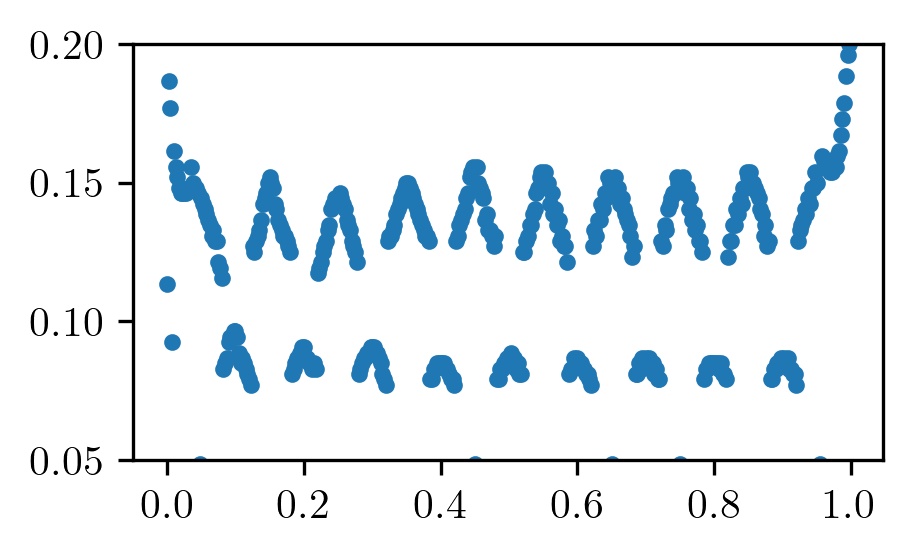

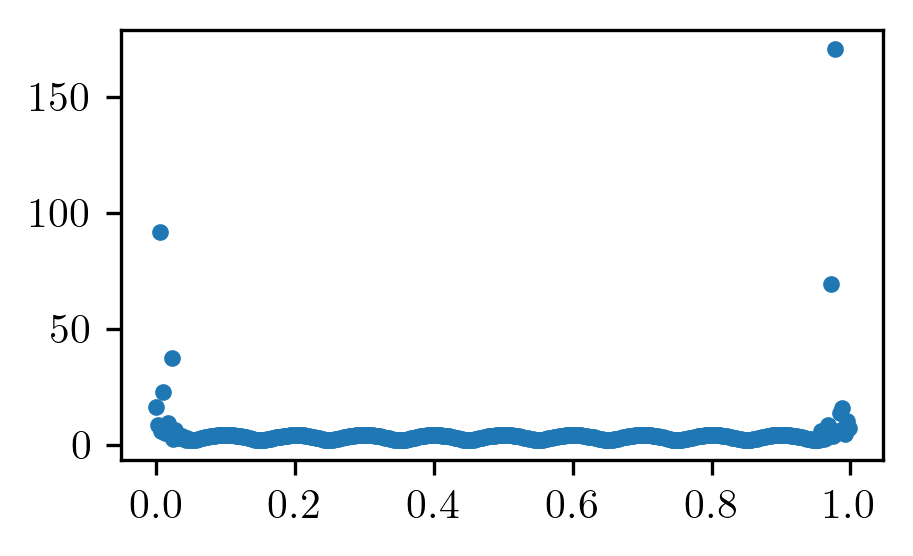

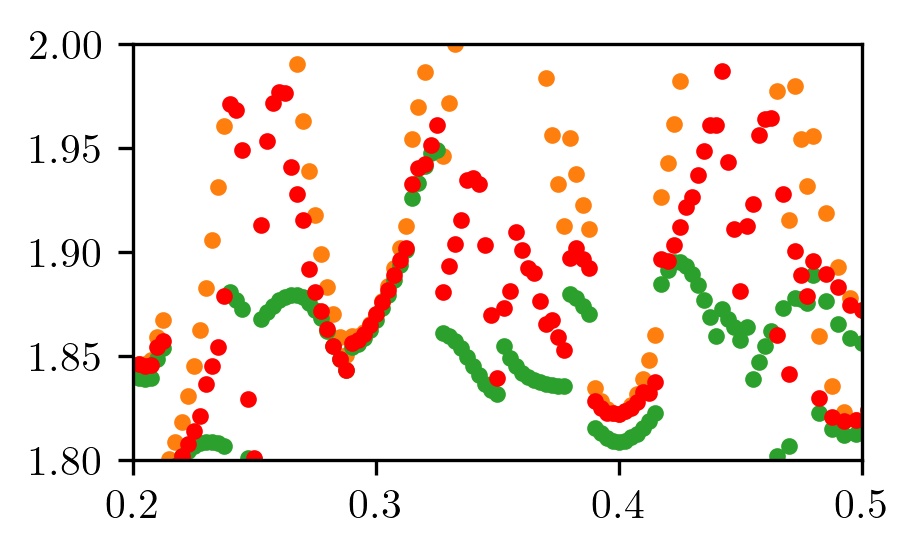

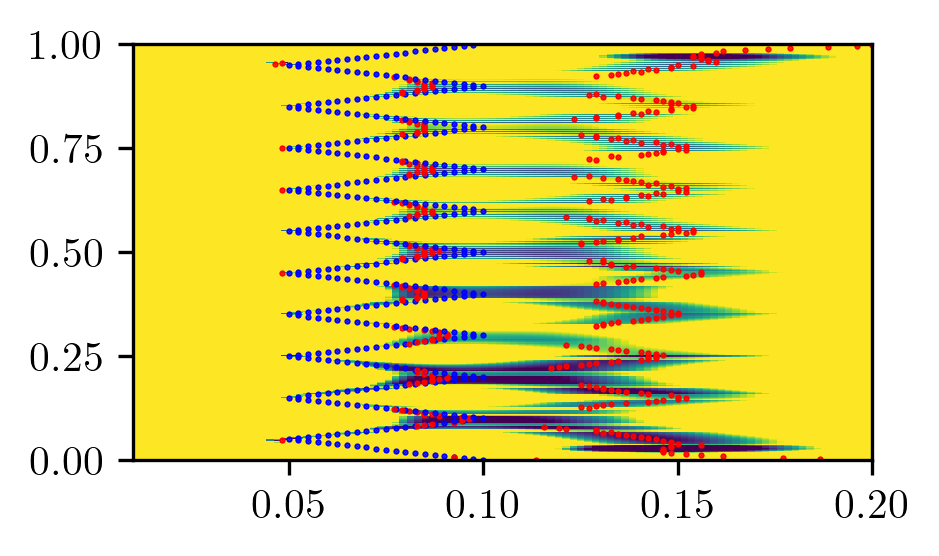

In [20]:
plt.plot(mu_validation, sgm_opt, "C0.")
plt.ylim(0.05, 0.2)
plt.show()

ind = np.argmin(np.abs(sgms-sigma))
plt.plot(mu_validation, e[:, ind], "C0.")

ind = np.argmin(np.abs(sgms-2*sigma))
fig, ax = plt.subplots()
plt.plot(mu_validation, e[:, ind], "C1.")
plt.plot(mu_validation, np.min(e, axis=1), "C2.")
plt.xlim(0.2, 0.5)
plt.ylim(1.8, 2.0)
left, right, bottom, top = 0.01, 0.2, 0, 1

fig, ax2 = plt.subplots()
plt.imshow(e, vmin=1.8, vmax=1.9, extent=(left, right, bottom, top), origin="lower", interpolation="nearest")
plt.gca().set_aspect("auto")
for p, m in enumerate(mu_validation):
    d = np.min(np.abs(m-mu_train))
    ind2 = np.argmin(np.abs(sgms - (sigma+1*d)))
    
    ax.plot(m, e[p, ind2], "r.")
    plt.plot(sigma+1*d, m, "b.", ms=1)

    ind = np.argmin(e[p, :])
    plt.plot(sgms[ind], m, "r.", ms=1)
plt.show()

In [19]:
asd

NameError: name 'asd' is not defined

In [ ]:
sigmas = np.linspace(0, 100, 1001, endpoint=True)[1:]
#sigmas[-1] = 18.768
e1 = np.zeros_like(sigmas)
e2 = np.zeros_like(sigmas)
e3 = np.zeros_like(sigmas)
e_xi1 = np.zeros_like(sigmas)
e_xi2 = np.zeros_like(sigmas)
ground_truth = np.c_[bump(x, xi[0]), bump(x, xi[1])]
for i, s in enumerate(sigmas):
    for j, mu_j in enumerate(mu):
        X_c[:, j] = gaussian_filter1d(X[:, j], s, mode=mode, cval=0.0)
    U_c, S_c, VT_c = np.linalg.svd(X_c, False)
    U_c, S_c, VT_c = U_c[:, :rank], S_c[:rank], VT_c[:rank]

    VT_intp_c = predict(VT_c, grid, rank, xi)
    X_test_intp_s = (U_c*S_c) @ VT_intp_c
    X_test_intp_s_post = np.zeros_like(X_test_intp_X_test_intp)
    for j in range(len(xi)):
        ind = np.argpartition(X_test_intp_s[:, j], -30)[-30:]
        X_test_intp_s_post[ind, j] = 1
    #print(np.sum(bump(x, 0.35) > .5), np.sum(X_test_intp_s_post[:, 0] > .5))

    e1[i] = np.sum((ground_truth-X_test_intp)**2)**.5
    e2[i] = np.sum((ground_truth-X_test_intp_s)**2)**.5
    e3[i] = np.sum((ground_truth-X_test_intp_s_post)**2)**.5
    e_xi1[i] = np.sum((ground_truth[:, 0]-X_test_intp_s_post[:, 0])**2)**.5
    e_xi2[i] = np.sum((ground_truth[:, 1]-X_test_intp_s_post[:, 1])**2)**.5
    if np.round(s, decimals=2) in [0.0, 30., 50]:
        print(s, )
        fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
        #plt.plot(x, X_test_intp_s_post, "r.")
        #plt.plot(x, X_test_intp_s_post, "r.")
        plt.plot(x, ground_truth[:, 0], "kx--", ms=4, lw=1, markevery=(0, markevery), label="true solution")
        plt.plot(x, X_test_intp[:, 0], "C0o-", ms=4, lw=1, markevery=(15, markevery), label="standard ROM")
        plt.plot(x, X_test_intp_s[:, 0], "C1--", ms=4, lw=1, label="convolution + ROM")
        plt.plot(x, X_test_intp_s_post[:, 0], "C2|-", ms=4, lw=1, markevery=(30, markevery), label="convolution + ROM + post processing")
        plt.legend()
        plt.xlabel("x")
        plt.ylabel("y")
        #plt.title("{:.3f}, {:.3f}, {:.3f}".format(e1[i], e2[i], e3[i]))
        ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
        ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
        plt.grid(True, which='minor', linestyle='--', lw=.25)
        plt.grid(True, which='major', linestyle='-')
        plt.show()
        

In [ ]:
markevery_sig = 0.1
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
ax.plot(sigmas, e1, "C0o-", markevery=markevery_sig, ms=4, label="standard ROM")
ax.plot(sigmas, e2, "C1--", markevery=markevery_sig, ms=4, label="convolution + ROM")
ax.plot(sigmas, e3, "C2x-", markevery=markevery_sig, ms=4, label="convolution + ROM + post-processing")
#ax.plot(sigmas, e3*e2, "k--", markevery=markevery_sig, ms=4, label="convolution + ROM + post-processing")
plt.xlabel("$\sigma$")
plt.ylabel("$L_2- error$")
plt.legend()
ax.set_xticks(np.linspace(0, 100, 21, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 10, 21, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
#plt.ylim([0, 0.1])
plt.show()
print(sigmas[e1>e3])
print(sigmas[0==e3])

In [ ]:
_sigma = 77.8
_X_c = np.zeros_like(X_c)
for j, mu_j in enumerate(mu):
    _X_c[:, j] = gaussian_filter1d(X[:, j], _sigma, mode=mode, cval=0.0)
U_c, S_c, VT_c = np.linalg.svd(_X_c, False)
U_c, S_c, VT_c = U_c[:, :rank], S_c[:rank], VT_c[:rank]
e1_m = np.zeros_like(x)
e2_m = np.zeros_like(x)
e3_m = np.zeros_like(x)

for i, _mu_ in enumerate(x[x<=0.9]):
    
    _ground_truth = bump(x, _mu_)

    _VT_intp = predict(VT, grid, rank, [_mu_])
    _X_intp = (U*S) @ _VT_intp

    _VT_intp_c = predict(VT_c, grid, rank, [_mu_])
    _X_intp_c = (U_c*S_c) @ _VT_intp_c

    _X_intp_c_post = np.zeros_like(_X_intp_c)
    for j in range(len(xi)):
        ind = np.argpartition(_X_intp_c[:, 0], -30)[-30:]
        _X_intp_c_post[ind, 0] = 1
    
    e1_m[i] = np.mean((_ground_truth-_X_intp[:, 0])**2)**.5
    e2_m[i] = np.mean((_ground_truth-_X_intp_c[:, 0])**2)**.5
    e3_m[i] = np.mean((_ground_truth-_X_intp_c_post[:, 0])**2)**.5
    if np.round(_mu_, decimals=4) in [0.125, 0.35]:
        print(_mu_, _sigma)
        fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
        #plt.plot(x, X_intp_c_post, "r.")
        #plt.plot(x, X_intp_c_post, "r.")
        plt.plot(x, _ground_truth, "kx--", ms=4, lw=1, markevery=(0, markevery), label="true solution")
        plt.plot(x, _X_intp[:, 0], "C0o-", ms=4, lw=1, markevery=(15, markevery), label="standard ROM")
        plt.plot(x, _X_intp_c[:, 0], "C1--", ms=4, lw=1, label="convolution + ROM")
        plt.plot(x, _X_intp_c_post[:, 0], "C2|-", ms=4, lw=1, markevery=(30, markevery), label="convolution + ROM + post processing")
        plt.legend()
        plt.xlabel("x")
        plt.ylabel("y")
        #plt.title("{:.3f}, {:.3f}, {:.3f}".format(e1[i], e2[i], e3[i]))
        ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
        ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
        plt.grid(True, which='minor', linestyle='--', lw=.25)
        plt.grid(True, which='major', linestyle='-')
        ax.text(0.52, 0.12, "$||e||_{L_2}"+"={:.2f}$".format(e3[i]), fontsize=6)
        plt.show()
np.linspace(0, 1, 11, endpoint=True)


In [ ]:
markevery = 40
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
ax.plot(x[:i], e1_m[:i], "C0o-", ms=4, markevery=(20, markevery), label="standard ROM")
ax.plot(x[:i], e2_m[:i], "C1--", ms=4, markevery=markevery, label="convolution + ROM")
ax.plot(x[:i], e3_m[:i], "C2x-", ms=4, markevery=(20, markevery), label="convolution + ROM + post processing")
plt.legend()
ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, .4, 19, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
plt.xlabel("$\mu$")
plt.ylabel("error")

In [ ]:
print(np.mean(e1_m[:i]), np.mean(e3_m[:i]), np.mean(e3_m[:i])/np.mean(e1_m[:i]))